# LSTM Custom Experiments (Pure Architecture)

This notebook encapsulates the training, testing, and evaluation logic into reusable functions, allowing us to easily run and evaluate different Pure LSTM configurations using dictionary configs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import mlflow

from custom_lstm.utils import ew_acf
from tests.ablation_studies.config import ArchitectureType, ExperimentConfig, DataMode, LossType
from tests.ablation_studies.data_loader import load_data
from tests.ablation_studies.train import seed_everything, run_experiment
import tests.ablation_studies.model_setup  # Registers the models

device = torch.device("cuda" if not torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

Using device: cpu
Device name: NVIDIA GeForce RTX 4050 Laptop GPU


### Helper Functions

We encapsulate the experiment running, data splitting visualization, predictions plotting, and stress testing into functions to avoid code duplication.


In [2]:
def run_lstm_experiment(data_path, config_kwargs, experiment_name="Notebook_Presentation", run_name=None):
    seed_everything(42)

    config = ExperimentConfig(data_path=data_path, **config_kwargs)

    if run_name:
        config.run_name = run_name
    config.experiment_name = experiment_name

    mlflow.set_experiment(config.experiment_name)
    results = run_experiment(config, patience=30)

    print(f"\nTraining complete! Best Val Loss: {results['best_val_loss']:.6f}")
    print(f"Model logged to MLflow Run ID: {results['run_id']}")

    return results, config

In [3]:
def get_data_tensors(data_path, window_size):
    data_dict, scaler = load_data(data_path, window_size=window_size)
    mode = DataMode.WINDOWED
    mode_train = data_dict.train.get_by_mode(mode)
    mode_val = data_dict.val.get_by_mode(mode)
    mode_test = data_dict.test.get_by_mode(mode)

    X_train, y_train = mode_train.X, mode_train.Y
    X_val, y_val = mode_val.X, mode_val.Y
    X_test, y_test = mode_test.X, mode_test.Y

    print("\n--- Shapes ---")
    print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"X_val: {X_val.shape} | y_val: {y_val.shape}")
    print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")

    return scaler, X_train, y_train, X_val, y_val, X_test, y_test

In [4]:
def plot_data(train: torch.Tensor, val: torch.Tensor, test: torch.Tensor):

    plt.figure(figsize=(15, 6))
    train_len = train.squeeze().shape[0]
    val_len = val.squeeze().shape[0]
    test_len = test.squeeze().shape[0]

    train_offset = np.array(list(range(0, train_len)))
    val_offset = np.array(list(range(train_len + 1, train_len + val_len + 1)))
    test_offset = np.array(list(range(train_len + val_len + 1, train_len + val_len + test_len + 1)))

    plt.plot(train_offset, train.squeeze(), label=r"Train Data $(\mathbf{X})$", alpha=0.7)
    plt.plot(val_offset, val.squeeze(), label=r"Val Data $(\mathbf{X})$", alpha=0.7)
    plt.plot(test_offset, test.squeeze(), label=r"Test Data $(\mathbf{X})$", alpha=0.7)

    plt.title("Train/Test/Val Split")
    plt.xlabel("Time Step")
    plt.legend()
    plt.show()

In [5]:
def test_model(trained_model, X_ref, y_ref, scaler):
    trained_model.eval()
    with torch.no_grad():
        trained_model.reset_state()
        y_pred, telemetry = trained_model(X_ref)

    predict_test_plot = scaler.inverse_transform(y_pred.detach().cpu().numpy().reshape(-1, 1))
    real_test_plot = scaler.inverse_transform(y_ref.detach().cpu().numpy().reshape(-1, 1))

    plt.figure(figsize=(12, 6))
    plt.plot(real_test_plot, label="Actual Test Data")
    plt.plot(predict_test_plot, label="Predicted Test Data", linestyle="--")
    plt.title("Predictions on Test Data")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

    return y_pred, telemetry

In [6]:
def run_stress_test(trained_model, X_val, y_val, device, WARM_UP=1000, GEN_STEPS=500):
    warmup_preds = []
    generated_preds = []

    print(f"\nStarting Stateless Experiment: {WARM_UP} Warm-up + {GEN_STEPS} Generation...")

    # Warm-Up
    with torch.no_grad():
        trained_model.eval()
        trained_model.reset_state()
        warmup_window = X_val[:, :WARM_UP, :].to(device)
        pred, _ = trained_model(warmup_window)

    # Generation
    with torch.no_grad():
        trained_model.eval()
        window = X_val[:, WARM_UP : WARM_UP + 1, :].to(device)

        for t in range(GEN_STEPS):
            gen_pred, _ = trained_model(window)
            generated_preds.append(gen_pred.squeeze().detach().cpu().numpy())
            new_val_tensor = torch.tensor([[[gen_pred.item()]]], device=device)
            window = torch.cat((window[:, :, 1:], new_val_tensor), dim=2)

    plt.figure(figsize=(14, 6))
    plt.plot(range(WARM_UP), pred.squeeze().detach().cpu().numpy(), label="Warm-Up (One-Step Ahead)", color="green", linestyle="--", linewidth=2)
    plt.plot(range(WARM_UP, WARM_UP + GEN_STEPS), generated_preds, label="Hallucination (Drift)", color="tab:red", linestyle="--", linewidth=2)

    y_val_plot = y_val[:, : WARM_UP + GEN_STEPS, :].squeeze()
    if isinstance(y_val_plot, torch.Tensor):
        y_val_plot = y_val_plot.cpu().numpy()

    plt.plot(range(WARM_UP + GEN_STEPS), y_val_plot, label="Ground Truth", color="black", alpha=0.3, linewidth=3)
    plt.title("Stress Test: Warm-up vs Generation")
    plt.legend()
    plt.show()

### 0. Dataset


In [7]:
data_path = "C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv"

In [8]:
WINDOW_SIZE = 1
EPOCHS = 200
HIDDEN_SIZE = 64
OUTPUT_SIZE = 1
LEARNING_RATE = 0.005
BPTT_STEPS = 50


--- Shapes ---
X_train: torch.Size([1, 9373, 1]) | y_train: torch.Size([1, 9373, 1])
X_val: torch.Size([1, 2007, 1]) | y_val: torch.Size([1, 2007, 1])
X_test: torch.Size([1, 2009, 1]) | y_test: torch.Size([1, 2009, 1])


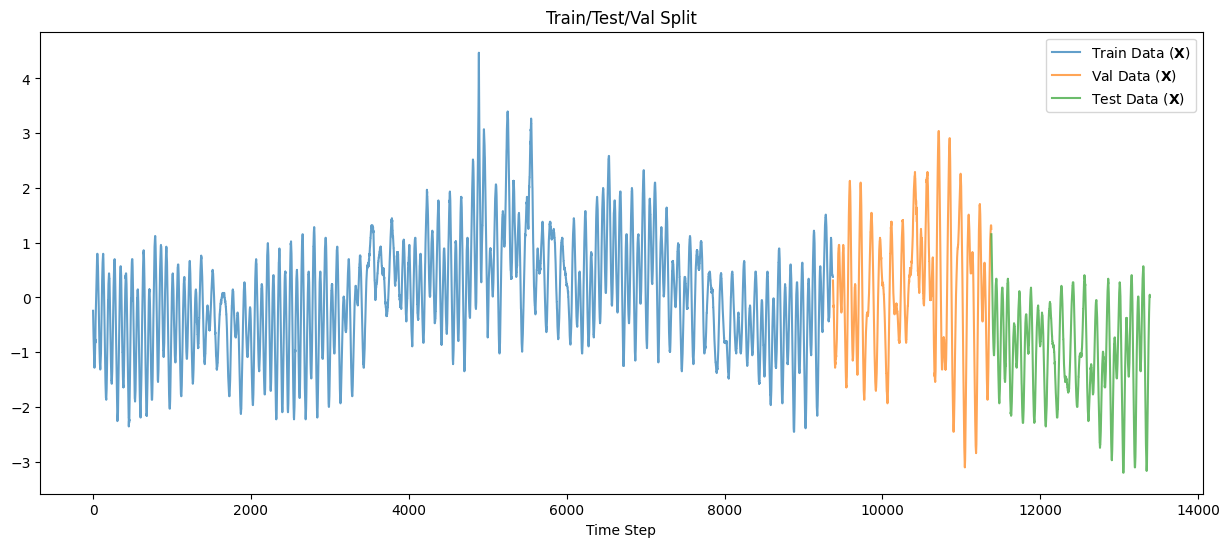

In [9]:
scaler, X_train, y_train, X_val, y_val, X_test, y_test = get_data_tensors(data_path, window_size=WINDOW_SIZE)
plot_data(X_train, X_val, X_test)

C:\Users\Luis\Documents\ML-AI-Projects\custom-lstm\custom_lstm\utils.py:128: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ts = torch.tensor(time_series, dtype=torch.float32)
C:\Users\Luis\AppData\Local\Temp\ipykernel_8128\1187793099.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


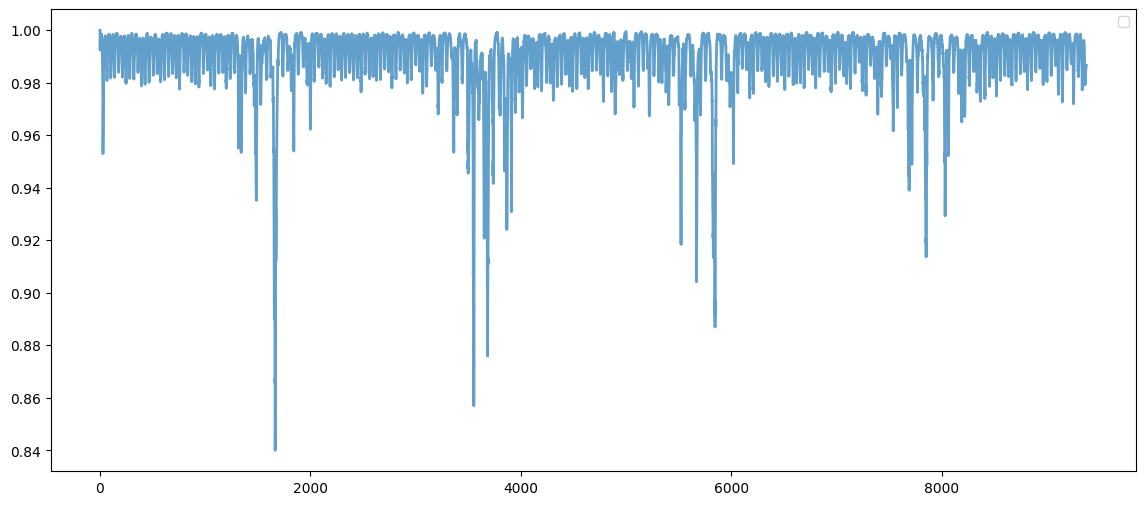

In [10]:
time_series = X_train.squeeze().detach().clone()
auto_corr = ew_acf(time_series=time_series, lag=1, lambda_=0.9)
plt.figure(figsize=(14, 6))
# plt.plot(time_series, alpha=0.7)
plt.plot(auto_corr, alpha=0.7, linewidth=2, label="")
plt.title("")
plt.legend()
plt.show()

### 1. Pure Architecture Experiment

Running the model with Pure LSTM Architecture and MSE loss.


In [12]:
config_mse = {
    "architecture": ArchitectureType.LSTM_CUSTOM_PURE,
    "data_mode": DataMode.PURE,
    "loss_type": LossType.MSE,
    "model_kwargs": {"input_size": WINDOW_SIZE, "hidden_size": HIDDEN_SIZE, "output_size": 1},
    "window_size": WINDOW_SIZE,
    "epochs": EPOCHS,
    "lr": LEARNING_RATE,
    "bptt_steps": BPTT_STEPS,
}

results_mse, config_mse_obj = run_lstm_experiment(data_path=data_path, config_kwargs=config_mse, run_name="LSTM_Custom_Pure_MSE")

Loading data from C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv...
Building ArchitectureType.LSTM_CUSTOM_PURE...
Number of parameters: 16961
Model and tensors are running on: cpu
────────────────────────────────────────────────────────────
  Experiment Pipeline Summary
────────────────────────────────────────────────────────────
  Architecture:    ArchitectureType.LSTM_CUSTOM_PURE
  Data mode:       DataMode.PURE (input_size=1)
  Loss:            LossType.MSE
  Trainer:         TrainerStrategyType.TBPTT
  BPTT steps:      50
  Dataset:         aqua_alta (C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv)
  Experiment:      Notebook_Presentation
────────────────────────────────────────────────────────────
Epoch   1/200  |  Train MSE: 0.03994  |  Val MSE: 0.00435


KeyboardInterrupt: 

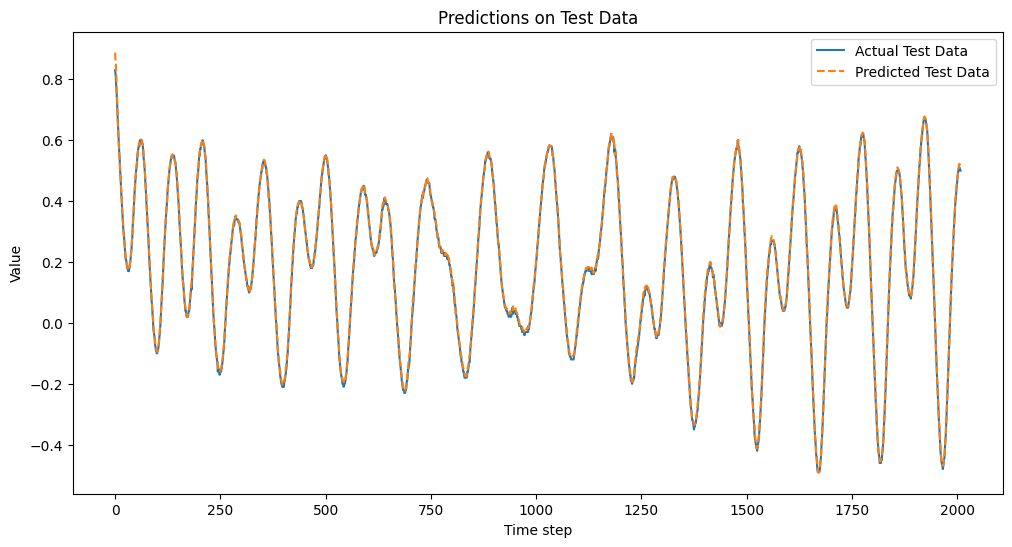


Starting Stateless Experiment: 1000 Warm-up + 500 Generation...


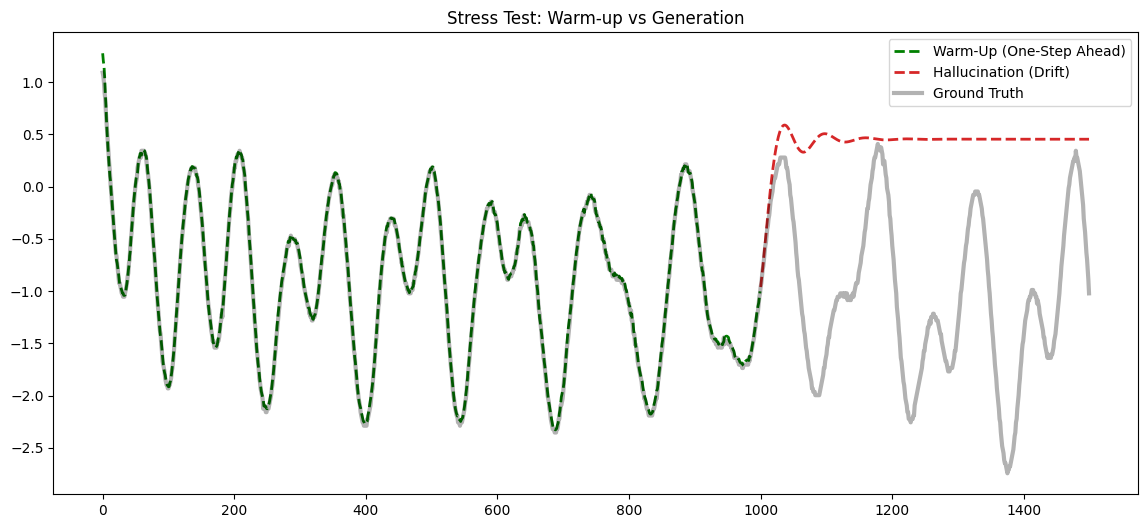

In [20]:
model_mse = results_mse["model"].to(device)

y_pred_mse, telemetry_mse = test_model(model_mse, X_test.to(device), y_test.to(device), scaler)
run_stress_test(model_mse, X_test.to(device), y_test.to(device), device)


### 2. Pure Architecture Experiment

Running the model with Pure LSTM Architecture and EW-ACF Broadcast loss.


In [13]:
config_ewacf = {
    "architecture": ArchitectureType.LSTM_CUSTOM_PURE,
    "data_mode": DataMode.PURE,
    "loss_type": LossType.EWACF_BROADCAST,
    "model_kwargs": {"input_size": WINDOW_SIZE, "hidden_size": HIDDEN_SIZE, "output_size": 1},
    "window_size": WINDOW_SIZE,
    "epochs": EPOCHS,
    "lr": LEARNING_RATE,
    "bptt_steps": BPTT_STEPS,
    "ewacf_alpha": 0.2,
    "ewacf_lambda": 0.85,
    "ewacf_lag": 2,
    "ewacf_threshold": 0.1,
}

results_ewacf, config_ewacf_obj = run_lstm_experiment(data_path=data_path, config_kwargs=config_ewacf, run_name="LSTM_Custom_Pure_EWACF")


Loading data from C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv...
Building ArchitectureType.LSTM_CUSTOM_PURE...
Number of parameters: 16961
Model and tensors are running on: cpu
────────────────────────────────────────────────────────────
  Experiment Pipeline Summary
────────────────────────────────────────────────────────────
  Architecture:    ArchitectureType.LSTM_CUSTOM_PURE
  Data mode:       DataMode.PURE (input_size=1)
  Loss:            LossType.EWACF_BROADCAST (α=0.2, λ=0.85, lag=2, θ=0.1)
  Trainer:         TrainerStrategyType.EWACF_TBPTT
  BPTT steps:      50
  Dataset:         aqua_alta (C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv)
  Experiment:      Notebook_Presentation
────────────────────────────────────────────────────────────
Epoch   1/200  |  Train MSE: 0.03244  |  Val MSE: 0.00359
Epoch  10/200  |  Train MSE: 0.00111  |  Val MSE: 0.00247
Epoch  20/200  |  Train MSE: 0.00144  |  Val MSE: 0.

2026/05/18 18:38:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Early stopping at epoch 46 (no improvement for 30 epochs)


2026/05/18 18:38:53 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/18 18:39:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Training complete! Best Val Loss: 0.000838
Model logged to MLflow Run ID: df38543694ff471d831b3430794eeca3


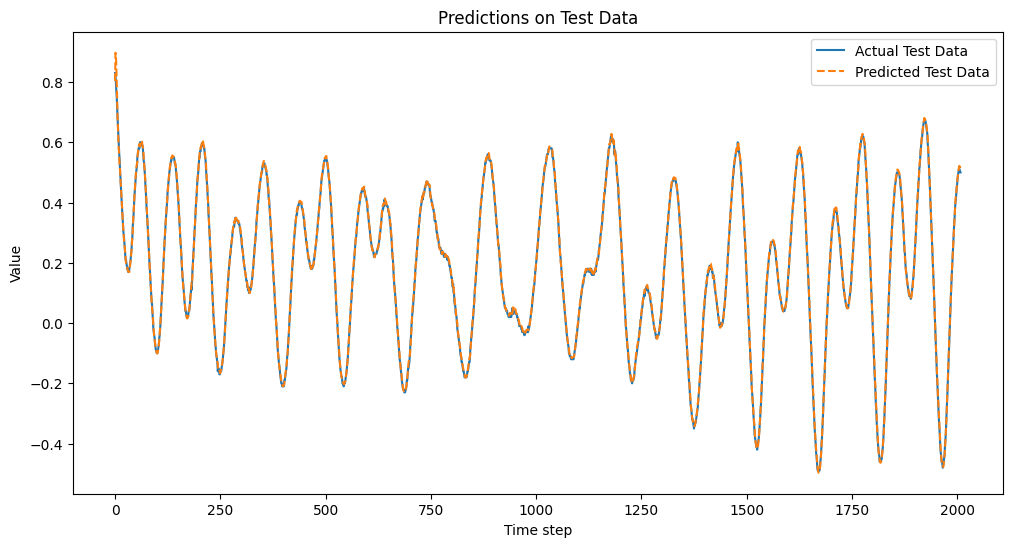


Starting Stateless Experiment: 1000 Warm-up + 500 Generation...


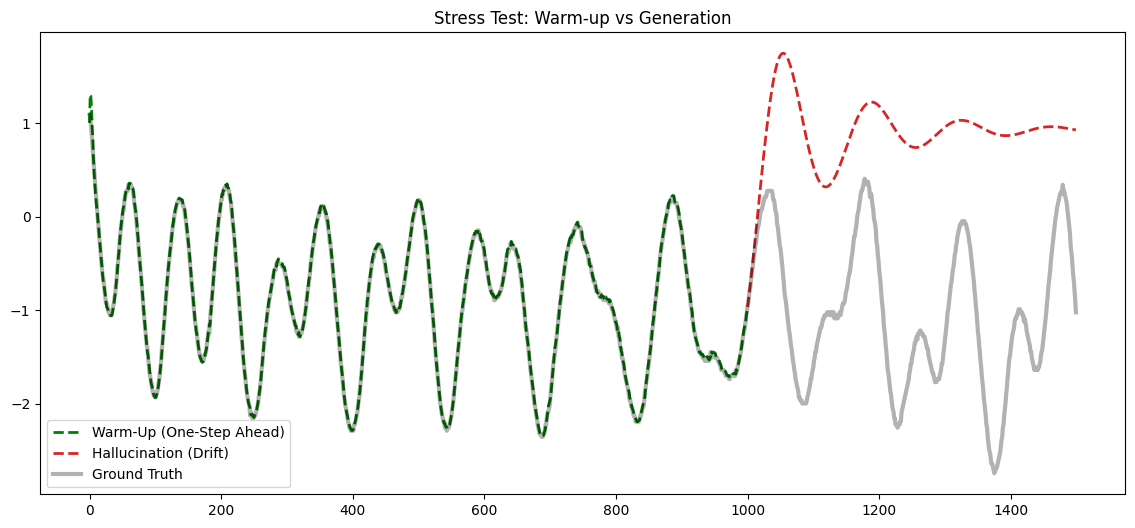

In [14]:
model_ewacf = results_ewacf["model"].to(device)

y_pred_ewacf, telemetry_ewacf = test_model(model_ewacf, X_test.to(device), y_test.to(device), scaler)
run_stress_test(model_ewacf, X_test.to(device), y_test.to(device), device)


In [15]:
fg_ewacf = telemetry_ewacf.forget_gates.detach().cpu().flatten().numpy()
fg_mse = telemetry_mse.forget_gates.detach().cpu().flatten().numpy()
print(fg_ewacf)

[0.55283195 0.6877838  0.5274615  ... 0.4692947  0.44496277 0.62874454]


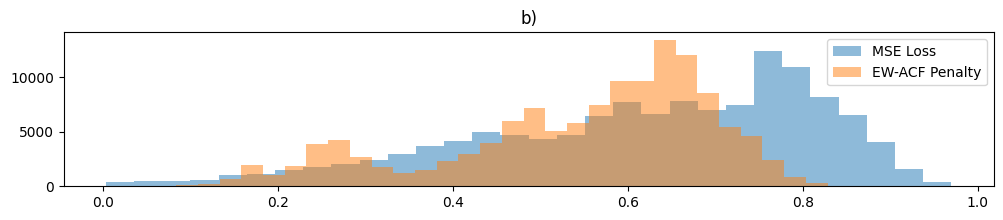

In [ ]:
fg_ewacf = telemetry_ewacf.forget_gates.detach().cpu().flatten().numpy()
fg_mse = telemetry_mse.forget_gates.detach().cpu().flatten().numpy()

plt.hist(fg_mse, bins=30, alpha=0.5, label="MSE Loss")
plt.hist(fg_ewacf, bins=30, alpha=0.5, label="EW-ACF Penalty")
plt.title("b)")
plt.legend()
plt.show()